# 05 — XGBoost Training (GPU Accelerated)
This notebook trains an XGBoost model using Google Colab's GPU for speed. It follows the team's shared CV strategy to ensure ensembling compatibility.

**Outputs:**
1. `submissions/xgb_submission.csv` — Individual model submission.
2. `pickles/xgb_oof.pkl` — Out-Of-Fold probabilities for ensembling.
3. `pickles/xgb_test_preds.pkl` — Test probabilities for ensembling.

In [1]:
# Mount Google Drive - run this first on Colab
from google.colab import drive
drive.mount('/content/drive')

# Set your project path on Drive - change this if your folder name is different
DRIVE_PATH = '/content/drive/MyDrive/santander-customer-satisfaction/'
PICKLE_DIR = DRIVE_PATH + 'pickles/'
SUBMIT_DIR = DRIVE_PATH + 'submissions/'

import os
os.makedirs(SUBMIT_DIR, exist_ok=True)
print('Drive mounted. Paths set.')

Mounted at /content/drive
Drive mounted. Paths set.


In [2]:
import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.2.0


## 1. Load Data & Shared CV Folds

In [3]:
# Load clean datasets from Drive
#train = pd.read_pickle(f'{PICKLE_DIR}train_clean.pkl')
#test = pd.read_pickle(f'{PICKLE_DIR}test_clean.pkl')
train = pd.read_pickle(f'{PICKLE_DIR}train_advanced.pkl')
test = pd.read_pickle(f'{PICKLE_DIR}test_advanced.pkl')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Separate features and target
X = train.drop(columns=['TARGET', 'ID'], errors='ignore')
y = train['TARGET']
test_features = test.drop(columns=['ID'], errors='ignore')

# Align columns
test_features = test_features[X.columns]

# Load identical CV folds
with open(f'{PICKLE_DIR}cv_fold_indices.pkl', 'rb') as f:
    cv_folds = pickle.load(f)

print(f"Loaded {len(cv_folds)} CV folds.")

Train shape: (76020, 104)
Test shape: (75818, 103)
Loaded 5 CV folds.


## 2. Train XGBoost (GPU Accelerated)

In [6]:
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

# Lists to store metrics and models
fold_aucs = []
models = []

# XGBoost Parameters for GPU
# xgb_params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'auc',
#     'learning_rate': 0.05,
#     'max_depth': 6,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8,
#     'tree_method': 'hist',  # Changed from 'gpu_hist' based on error message
#     'random_state': 42,
#     'n_jobs': -1,
#     'early_stopping_rounds': 100
# }

# OPTIMIZED XGBOOST PARAMETERS
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'tree_method': 'hist',
    'lambda': 0.40525764696520994,
    'alpha': 0.004209910021977267,
    'subsample': 0.8492306700124232,
    'colsample_bytree': 0.4697530115943648,
    'max_depth': 4,
    'min_child_weight': 2,
    'eta': 0.01704610324611452,
    'gamma': 0.00031128353436984593,
    'n_estimators': 2000,
    'random_state': 42
}


print("Starting XGBoost Training (GPU)...")
print("-" * 40)

for fold_dict in cv_folds:
    fold = fold_dict['fold']
    train_idx = fold_dict['train_idx']
    val_idx = fold_dict['val_idx']

    # Split data
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    # Train model
    model = xgb.XGBClassifier(**xgb_params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=200
    )

    models.append(model)

    # Predict on validation fold
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    # Evaluate fold
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold} AUC: {fold_auc:.5f}")

    # Predict on Test set (accumulate)
    test_preds += model.predict_proba(test_features)[:, 1] / len(cv_folds)

print("-" * 40)
print(f"Mean CV AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")

Starting XGBoost Training (GPU)...
----------------------------------------
[0]	validation_0-auc:0.79712
[200]	validation_0-auc:0.83145
[400]	validation_0-auc:0.83361
[600]	validation_0-auc:0.83365
[800]	validation_0-auc:0.83301
[1000]	validation_0-auc:0.83236
[1200]	validation_0-auc:0.83118
[1400]	validation_0-auc:0.83044
[1600]	validation_0-auc:0.82969
[1800]	validation_0-auc:0.82880
[1999]	validation_0-auc:0.82792
Fold 0 AUC: 0.82792
[0]	validation_0-auc:0.81419
[200]	validation_0-auc:0.84126
[400]	validation_0-auc:0.84289
[600]	validation_0-auc:0.84326
[800]	validation_0-auc:0.84276
[1000]	validation_0-auc:0.84225
[1200]	validation_0-auc:0.84179
[1400]	validation_0-auc:0.84092
[1600]	validation_0-auc:0.84017
[1800]	validation_0-auc:0.83944
[1999]	validation_0-auc:0.83850
Fold 1 AUC: 0.83850
[0]	validation_0-auc:0.82074
[200]	validation_0-auc:0.84536
[400]	validation_0-auc:0.84625
[600]	validation_0-auc:0.84582
[800]	validation_0-auc:0.84523
[1000]	validation_0-auc:0.84402
[1200]	va

## 3. Save OOF & Test Predictions for the Ensemble

In [7]:
# Save OOF predictions
oof_df = pd.DataFrame({'ID': train['ID'], 'xgb_pred': oof_preds})
oof_df.to_pickle(f'{PICKLE_DIR}xgb_oof.pkl')

# Save Test predictions
test_preds_df = pd.DataFrame({'ID': test['ID'], 'xgb_pred': test_preds})
test_preds_df.to_pickle(f'{PICKLE_DIR}xgb_test_preds.pkl')

print("✅ Saved XGBoost probabilities to Drive! (Ready for Ensembling!)")

✅ Saved XGBoost probabilities to Drive! (Ready for Ensembling!)


## 4. Feature Importance

/tmp/ipykernel_40950/480928636.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(25), palette='magma')


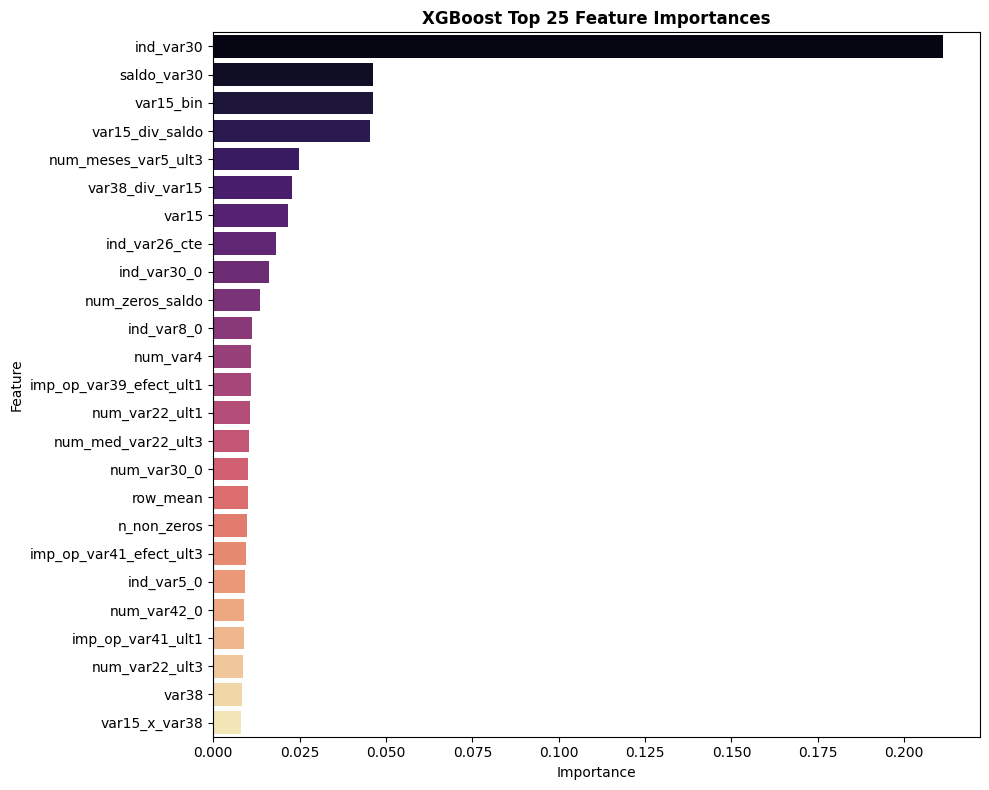

In [8]:
feature_importances = np.zeros(len(X.columns))
for model in models:
    feature_importances += model.feature_importances_ / len(models)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(25), palette='magma')
plt.title('XGBoost Top 25 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Kaggle Submission

In [9]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'TARGET': test_preds
})

submission_path = f'{SUBMIT_DIR}xgb_submission.csv'
submission.to_csv(submission_path, index=False)

print(f"✅ Kaggle Submission saved to {submission_path}")

✅ Kaggle Submission saved to /content/drive/MyDrive/santander-customer-satisfaction/submissions/xgb_submission.csv
